In [13]:
# ==========================================
# 1. IMPORTS AND SETUP
# ==========================================
!pip install lightgbm


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score
from collections import Counter
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [29]:


def load_data(sample_size=None):
    """
    Load the IEEE fraud detection dataset with debug messages.
    
    Args:
        sample_size (int or None): Number of rows to read from each CSV.
                                   If None, load the full dataset.
    """
    # Check what files exist
    print(" Files in current directory:", os.listdir())
    
    try:
        print(" Loading train_transaction.csv ...")
        train_transaction = pd.read_csv('train_transaction.csv', nrows=sample_size)
        
        print(" Loading train_identity.csv ...")
        train_identity = pd.read_csv('train_identity.csv', nrows=sample_size)
        
        print(" Loading test_transaction.csv ...")
        test_transaction = pd.read_csv('test_transaction.csv', nrows=sample_size)
        
        print(" Loading test_identity.csv ...")
        test_identity = pd.read_csv('test_identity.csv', nrows=sample_size)
        
        print(" Loading sample_submission.csv ...")
        sample_submission = pd.read_csv('sample_submission.csv')
        
        print(f" Training transaction data shape: {train_transaction.shape}")
        print(f" Training identity data shape: {train_identity.shape}")
        print(f" Test transaction data shape: {test_transaction.shape}")
        print(f" Test identity data shape: {test_identity.shape}")
        
        return train_transaction, train_identity, test_transaction, test_identity, sample_submission
    
    except FileNotFoundError as e:
        print(f"❌ File not found: {e.filename}")
        return None, None, None, None, None


# ========================
# USAGE
# ========================
train_transaction, train_identity, test_transaction, test_identity, sample_submission = load_data(sample_size=50000)


 Files in current directory: ['.git', '.gitattributes', '.ipynb_checkpoints', 'Frauddetection.ipynb', 'preprocessed_test_50k.csv', 'preprocessed_train_50k.csv', 'preprocessed_train_target_50k.csv', 'sample_submission.csv', 'submission_ensemble.csv', 'submission_lgb.csv', 'submission_lr.csv', 'submission_rf.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv']
 Loading train_transaction.csv ...
 Loading train_identity.csv ...
 Loading test_transaction.csv ...
 Loading test_identity.csv ...
 Loading sample_submission.csv ...
 Training transaction data shape: (50000, 394)
 Training identity data shape: (50000, 41)
 Test transaction data shape: (50000, 393)
 Test identity data shape: (50000, 41)


=== TRANSACTION DATA EXPLORATION ===
Shape: (50000, 394)
Memory usage: 173.3 MB
Missing values per column:
D7       47644
dist2    46645
D13      46322
D12      45903
D14      45672
D6       45175
D8       41250
D9       41250
M8       40776
M7       40776
dtype: int64

=== TARGET VARIABLE DISTRIBUTION ===
Non-fraud: 48,643 (97.29%)
Fraud: 1,357 (2.71%)


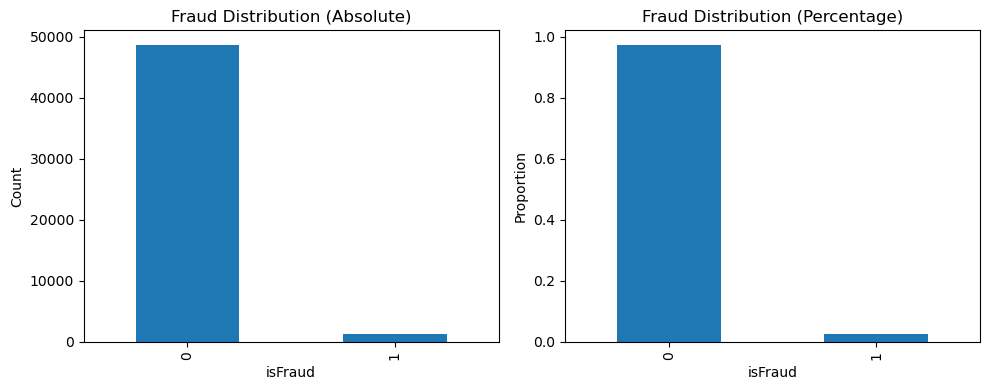


=== IDENTITY DATA EXPLORATION ===
Shape: (50000, 41)
Overlap with transaction data: 16456


In [15]:
# ==========================================
# 3. DATA EXPLORATION
# ==========================================

def explore_data(train_transaction, train_identity):
    """Explore the training data"""
    
    print("=== TRANSACTION DATA EXPLORATION ===")
    print(f"Shape: {train_transaction.shape}")
    print(f"Memory usage: {train_transaction.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Missing values per column:")
    print(train_transaction.isnull().sum().sort_values(ascending=False).head(10))
    
    print("\n=== TARGET VARIABLE DISTRIBUTION ===")
    fraud_counts = train_transaction['isFraud'].value_counts()
    fraud_rate = train_transaction['isFraud'].mean()
    print(f"Non-fraud: {fraud_counts[0]:,} ({100*(1-fraud_rate):.2f}%)")
    print(f"Fraud: {fraud_counts[1]:,} ({100*fraud_rate:.2f}%)")
    
    # Plot target distribution
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    train_transaction['isFraud'].value_counts().plot(kind='bar')
    plt.title('Fraud Distribution (Absolute)')
    plt.xlabel('isFraud')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    train_transaction['isFraud'].value_counts(normalize=True).plot(kind='bar')
    plt.title('Fraud Distribution (Percentage)')
    plt.xlabel('isFraud')
    plt.ylabel('Proportion')
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== IDENTITY DATA EXPLORATION ===")
    if train_identity is not None:
        print(f"Shape: {train_identity.shape}")
        print(f"Overlap with transaction data: {len(set(train_identity['TransactionID']) & set(train_transaction['TransactionID']))}")

# Explore the data
if train_transaction is not None:
    explore_data(train_transaction, train_identity)

In [16]:
#### REMOVED EDA AND GRAPHS OF REPORT 1 THIS IS JUST REPORT 2 WORK #### 

In [28]:
# ==========================================
# 4. DATA PREPROCESSING & FEATURE ENGINEERING
# ==========================================

def merge_datasets(transaction, identity):
    """
    Merge transaction and identity datasets on TransactionID.
    
    Args:
        transaction (pd.DataFrame): transaction table
        identity (pd.DataFrame or None): identity table
        
    Returns:
        pd.DataFrame: merged dataset
    """
    if identity is not None:
        merged = transaction.merge(identity, on='TransactionID', how='left')
        print(f"[merge_datasets] Merged shape: {merged.shape}")
        return merged
    else:
        print("[merge_datasets] No identity data, returning transaction only.")
        return transaction


def preprocess_data(train_df, test_df):
    """
    Full preprocessing & feature engineering for IEEE-CIS fraud detection.

    Steps:
        - Combine train and test for consistent transformations
        - Create transaction, time, email, device, card, address, UID, and user-level features
        - Drop very sparse columns
        - Handle missing values
        - Label-encode categorical features
        - Split back into processed train/test

    Returns:
        train_processed (pd.DataFrame): Preprocessed training features (no target)
        test_processed  (pd.DataFrame): Preprocessed test features
        target (pd.Series): Original training target (isFraud)
        label_encoders (dict): LabelEncoder objects for object columns
    """
    # Copy input to avoid modifying original data
    train = train_df.copy()
    test = test_df.copy()

    # Mark train/test rows and separate target
    train['is_train'] = 1
    test['is_train'] = 0
    target = train['isFraud'].copy() if 'isFraud' in train.columns else None
    if 'isFraud' in train.columns:
        train = train.drop(columns=['isFraud'])

    # Combine for consistent preprocessing
    combined_df = pd.concat([train, test], ignore_index=True)
    print(f"[preprocess] Combined shape: {combined_df.shape}")

    # ------------------------------------
    # Basic type safety for key columns
    # ------------------------------------
    if 'TransactionDT' in combined_df.columns:
        combined_df['TransactionDT'] = pd.to_numeric(
            combined_df['TransactionDT'], errors='coerce'
        ).fillna(0).astype(int)

    if 'TransactionAmt' in combined_df.columns:
        combined_df['TransactionAmt'] = pd.to_numeric(
            combined_df['TransactionAmt'], errors='coerce'
        ).fillna(0.0)

    # ------------------------------------
    # Transaction amount features
    # ------------------------------------
    if 'TransactionAmt' in combined_df.columns:
        # Log transform to reduce skew
        combined_df['TransactionAmt_log'] = np.log1p(combined_df['TransactionAmt'])

        # Decimal part (fraud often uses odd cents)
        combined_df['TransactionAmt_decimal'] = combined_df['TransactionAmt'] % 1

        # Compare to card1-level baseline (mean/std)
        if 'card1' in combined_df.columns:
            grp_mean = combined_df.groupby('card1')['TransactionAmt'].transform('mean')
            grp_std = combined_df.groupby('card1')['TransactionAmt'].transform('std').replace(0, np.nan)
            combined_df['Amt_to_mean'] = combined_df['TransactionAmt'] / (grp_mean + 1e-9)
            combined_df['Amt_to_std'] = combined_df['TransactionAmt'] / (grp_std + 1e-9)

    # ------------------------------------
    # Time-based features
    # ------------------------------------
    if 'TransactionDT' in combined_df.columns:
        combined_df['Transaction_hour'] = (combined_df['TransactionDT'] // 3600) % 24
        combined_df['Transaction_day'] = (combined_df['TransactionDT'] // 86400) % 7
        combined_df['Transaction_month'] = combined_df['TransactionDT'] // (86400 * 30)
        # Night-time transactions often riskier
        combined_df['is_night'] = (combined_df['Transaction_hour'] <= 6).astype(int)

    # ------------------------------------
    # Email domain features
    # ------------------------------------
    for col in ['P_emaildomain', 'R_emaildomain']:
        if col in combined_df.columns:
            combined_df[col] = combined_df[col].fillna('Unknown').astype(str)
            # Flag free email providers (frequently used in fraud)
            combined_df[f'{col}_is_free'] = combined_df[col].isin(
                ['gmail.com', 'yahoo.com', 'hotmail.com']
            ).astype(int)

    # ------------------------------------
    # Device features
    # ------------------------------------
    if 'DeviceInfo' in combined_df.columns:
        combined_df['DeviceInfo'] = combined_df['DeviceInfo'].fillna('Unknown').astype(str)
        # Keep only main device family
        combined_df['DeviceInfo_simple'] = combined_df['DeviceInfo'].str.split('/').str[0].str.lower()

    if 'DeviceType' in combined_df.columns:
        combined_df['DeviceType'] = combined_df['DeviceType'].fillna('Unknown').astype(str)

    # ------------------------------------
    # Card & address frequency (count encoding)
    # ------------------------------------
    freq_cols = [c for c in ['card1', 'card2', 'card3', 'card4', 'card5', 'addr1', 'addr2']
                 if c in combined_df.columns]
    for c in freq_cols:
        combined_df[c + '_freq'] = combined_df.groupby(c)[c].transform('count')

    # ------------------------------------
    # UID combinations (identity fingerprints)
    # ------------------------------------
    # uid: combinations of card/address/email that approximate a "user"
    if 'card1' in combined_df.columns:
        combined_df['uid'] = combined_df['card1'].astype(str)
    if set(['card1', 'card2']).issubset(combined_df.columns):
        combined_df['uid2'] = combined_df['card1'].astype(str) + '_' + combined_df['card2'].astype(str)
    if set(['card1', 'card2', 'addr1']).issubset(combined_df.columns):
        combined_df['uid3'] = (combined_df['card1'].astype(str) + '_' +
                               combined_df['card2'].astype(str) + '_' +
                               combined_df['addr1'].astype(str))
    if set(['card1', 'card2', 'addr1', 'P_emaildomain']).issubset(combined_df.columns):
        combined_df['uid4'] = (combined_df['card1'].astype(str) + '_' +
                               combined_df['card2'].astype(str) + '_' +
                               combined_df['addr1'].astype(str) + '_' +
                               combined_df['P_emaildomain'].astype(str))

    # Frequency encode UID combos
    for c in ['uid', 'uid2', 'uid3', 'uid4']:
        if c in combined_df.columns:
            combined_df[c + '_freq'] = combined_df.groupby(c)[c].transform('count')

    # ------------------------------------
    # User-level aggregations (card1 as user)
    # ------------------------------------
    if 'card1' in combined_df.columns and 'TransactionID' in combined_df.columns:
        combined_df['user_trans_count'] = combined_df.groupby('card1')['TransactionID'].transform('count')
        combined_df['user_mean_amt'] = combined_df.groupby('card1')['TransactionAmt'].transform('mean')
        combined_df['user_std_amt'] = combined_df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

    # ------------------------------------
    # Time-delta per uid3 (time since previous transaction)
    # ------------------------------------
    if 'TransactionDT' in combined_df.columns and 'uid3' in combined_df.columns:
        # store original order, sort by uid3 + time, compute diff, then restore
        combined_df = combined_df.reset_index().rename(columns={'index': 'orig_index'})
        combined_df = combined_df.sort_values(['uid3', 'TransactionDT']).reset_index(drop=True)
        combined_df['time_diff_uid3'] = combined_df.groupby('uid3')['TransactionDT'].diff().fillna(-1)
        combined_df = combined_df.sort_values('orig_index').drop(columns=['orig_index']).reset_index(drop=True)

    # ------------------------------------
    # Drop very sparse columns (>90% missing)
    # ------------------------------------
    missing_pct = combined_df.isnull().mean()
    drop_cols = missing_pct[missing_pct > 0.90].index.tolist()
    if drop_cols:
        combined_df = combined_df.drop(columns=drop_cols)
        print(f"[preprocess] Dropped {len(drop_cols)} columns with >90% missing values")

    # ------------------------------------
    # Handle missing values
    # ------------------------------------
    for col in combined_df.columns:
        if combined_df[col].dtype in ['float64', 'int64']:
            combined_df[col] = combined_df[col].fillna(combined_df[col].median())
        else:
            combined_df[col] = combined_df[col].fillna('Unknown').astype(str)

    # ------------------------------------
    # Label encoding for object columns
    # ------------------------------------
    categorical_cols = combined_df.select_dtypes(include=['object']).columns.tolist()
    # Don't encode TransactionID (keep as ID only)
    categorical_cols = [c for c in categorical_cols if c not in ['TransactionID']]

    label_encoders = {}
    print(f"[preprocess] Encoding {len(categorical_cols)} categorical columns...")
    for c in categorical_cols:
        le = LabelEncoder()
        combined_df[c] = le.fit_transform(combined_df[c].astype(str))
        label_encoders[c] = le

    # ------------------------------------
    # Final feature selection and split
    # ------------------------------------
    cols_to_remove = ['TransactionID', 'is_train']
    feature_cols = [col for col in combined_df.columns if col not in cols_to_remove]

    train_processed = combined_df[combined_df['is_train'] == 1][feature_cols].reset_index(drop=True)
    test_processed = combined_df[combined_df['is_train'] == 0][feature_cols].reset_index(drop=True)

    print(f"[preprocess] Final training set shape: {train_processed.shape}")
    print(f"[preprocess] Final test set shape: {test_processed.shape}")

    return train_processed, test_processed, target, label_encoders


# ==========================================
# 4.1 MERGE & PREPROCESS: FULL DATA
# ==========================================
if train_transaction is not None:
    # Merge transaction and identity tables
    train_merged = merge_datasets(train_transaction, train_identity)
    test_merged = merge_datasets(test_transaction, test_identity)

    # Run preprocessing + feature engineering on FULL dataset
    X_train, X_test, y_train, encoders = preprocess_data(train_merged, test_merged)


# # ==========================================
# # 4.2 SMALL-SUBSET TEST (required by assignment)
# # ==========================================
# # This demonstrates that preprocessing works on a small subset

# sample_n = 1000  # number of rows for subset test
# train_sample = train_merged.head(sample_n).copy()
# test_sample = test_merged.head(sample_n).copy()

# X_s_train, X_s_test, y_s_train, encs_s = preprocess_data(train_sample, test_sample)

# print(">>> Subset processed shapes:", X_s_train.shape, X_s_test.shape)
# print(">>> Subset target distribution:", y_s_train.value_counts(dropna=False).to_dict())

# # Save subset for submission (small example dataset + labels)
# X_s_train.to_csv("preprocessed_train_subset.csv", index=False)
# X_s_test.to_csv("preprocessed_test_subset.csv", index=False)
# y_s_train.to_frame(name='isFraud').to_csv("preprocessed_train_target_subset.csv", index=False)
# print("Saved: preprocessed_train_subset.csv, preprocessed_test_subset.csv, preprocessed_train_target_subset.csv")

# ==========================================
# CREATE 50K SUBSET FOR SUBMISSION
# ==========================================

subset_n = 50000

train_subset = train_merged.head(subset_n).copy()
test_subset  = test_merged.head(subset_n).copy()

print("Subset shapes before preprocessing:")
print("Train subset:", train_subset.shape)
print("Test subset:", test_subset.shape)

X_50k_train, X_50k_test, y_50k_train, encs_50k = preprocess_data(
    train_subset,
    test_subset
)

print("\nSubset shapes AFTER preprocessing:")
print("X_train:", X_50k_train.shape)
print("X_test:", X_50k_test.shape)
print("y_train:", y_50k_train.shape)

X_50k_train.to_csv("preprocessed_train_50k.csv", index=False)
X_50k_test.to_csv("preprocessed_test_50k.csv", index=False)
y_50k_train.to_frame(name="isFraud").to_csv("preprocessed_train_target_50k.csv", index=False)

print("\nSaved files:")
print("preprocessed_train_50k.csv")
print("preprocessed_test_50k.csv")
print("preprocessed_train_target_50k.csv")



[merge_datasets] Merged shape: (50000, 434)
[merge_datasets] Merged shape: (50000, 433)
[preprocess] Combined shape: (100000, 472)
[preprocess] Dropped 57 columns with >90% missing values
[preprocess] Encoding 41 categorical columns...
[preprocess] Final training set shape: (50000, 443)
[preprocess] Final test set shape: (50000, 443)
Subset shapes before preprocessing:
Train subset: (50000, 434)
Test subset: (50000, 433)
[preprocess] Combined shape: (100000, 472)
[preprocess] Dropped 57 columns with >90% missing values
[preprocess] Encoding 41 categorical columns...
[preprocess] Final training set shape: (50000, 443)
[preprocess] Final test set shape: (50000, 443)

Subset shapes AFTER preprocessing:
X_train: (50000, 443)
X_test: (50000, 443)
y_train: (50000,)

Saved files:
preprocessed_train_50k.csv
preprocessed_test_50k.csv
preprocessed_train_target_50k.csv


In [27]:
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------
#  VECTORIZED LOGISTIC REGRESSION (SCRATCH)
# -----------------------------------------------

class LogisticRegressionScratch:
    """
    A fully vectorized logistic regression classifier
    implemented from scratch using gradient descent.
    Supports class-balanced training for imbalanced data.
    """
    
    def __init__(self, lr=0.01, epochs=600):
        self.lr = lr
        self.epochs = epochs
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        # Add bias term
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        
        n, d = X.shape
        self.w = np.zeros(d)
        
        # Class balancing (like sklearn class_weight='balanced')
        pos = (y == 1).sum()
        neg = (y == 0).sum()
        w_pos = n / (2 * pos)
        w_neg = n / (2 * neg)
        class_weights = np.where(y == 1, w_pos, w_neg)
        
        for epoch in range(self.epochs):
            z = X.dot(self.w)
            y_pred = self.sigmoid(z)
            
            # Vectorized gradient
            errors = (y_pred - y) * class_weights
            grad = X.T.dot(errors) / n
            
            self.w -= self.lr * grad

            # Print every 100 epochs
            if epoch % 100 == 0:
                loss = -np.mean(
                    class_weights * (
                        y * np.log(y_pred + 1e-9) +
                        (1 - y) * np.log(1 - y_pred + 1e-9)
                    )
                )
                print(f"Epoch {epoch}/{self.epochs} - Loss: {loss:.4f}")

    def predict_proba(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        return self.sigmoid(X.dot(self.w))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)



# ---------------------------------------------------
# TRAIN SCRATCH MODEL ON 50,000-ROW SUBSET
# ---------------------------------------------------

subset_n = 50000
train_sample = train_merged.head(subset_n).copy()

# preprocess 50k subset
X_sub, _, y_sub, _ = preprocess_data(train_sample, train_sample.copy())

# Convert to numpy
X_np = X_sub.values
y_np = y_sub.values

# Scale features
scaler = StandardScaler()
X_np_scaled = scaler.fit_transform(X_np)

# Train scratch model
model = LogisticRegressionScratch(lr=0.005, epochs=600)
model.fit(X_np_scaled, y_np)

# Evaluate on subset
y_pred = model.predict_proba(X_np_scaled)

print("\n📊 Scratch Logistic Regression (Subset 50k)")
print("AUC:", roc_auc_score(y_np, y_pred))
print(classification_report(y_np, (y_pred >= 0.5).astype(int)))


[preprocess] Combined shape: (100000, 435)
[preprocess] Dropped 16 columns with >90% missing values
[preprocess] Encoding 41 categorical columns...
[preprocess] Final training set shape: (50000, 447)
[preprocess] Final test set shape: (50000, 447)
Epoch 0/600 - Loss: 0.6931
Epoch 100/600 - Loss: 0.5510
Epoch 200/600 - Loss: 0.5318
Epoch 300/600 - Loss: 0.5191
Epoch 400/600 - Loss: 0.5090
Epoch 500/600 - Loss: 0.5004

📊 Scratch Logistic Regression (Subset 50k)
AUC: 0.865072223748708
              precision    recall  f1-score   support

           0       0.99      0.66      0.80     48643
           1       0.07      0.87      0.12      1357

    accuracy                           0.67     50000
   macro avg       0.53      0.77      0.46     50000
weighted avg       0.97      0.67      0.78     50000



In [31]:
# ==========================================
# 5. MODEL TRAINING AND EVALUATION (FINAL CLEAN VERSION)
# ==========================================

def train_models(X_train, y_train, X_test):
    """
    Trains the required models for the assignment:
        1. LightGBM (state-of-the-art)
        2. Random Forest (tree-based baseline)
        3. Logistic Regression (linear baseline)
    Returns trained models + predictions.
    """

    models = {}
    predictions = {}

    # Train/validation split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train,
        test_size=0.2,
        random_state=42,
        stratify=y_train
    )

    print("Training models...")

    # ==========================================
    # 1. LIGHTGBM
    # ==========================================
    print("Training LightGBM...")

    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'random_state': 42
    }

    train_data = lgb.Dataset(X_tr, label=y_tr)
    valid_data = lgb.Dataset(X_val, label=y_val)

    lgb_model = lgb.train(
        lgb_params,
        train_data,
        valid_sets=[valid_data],
        num_boost_round=500,
        callbacks=[lgb.early_stopping(50)]
    )

    val_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
    print("LightGBM AUC:", roc_auc_score(y_val, val_pred_lgb))

    models["lgb"] = lgb_model
    predictions["lgb"] = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

    # ==========================================
    # 2. RANDOM FOREST
    # ==========================================
    print("Training Random Forest...")

    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_split=8,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)
    val_pred_rf = rf.predict_proba(X_val)[:, 1]
    print("Random Forest AUC:", roc_auc_score(y_val, val_pred_rf))

    models["rf"] = rf
    predictions["rf"] = rf.predict_proba(X_test)[:, 1]

    # ==========================================
    # 3. LOGISTIC REGRESSION (scaled)
    # ==========================================
    print("Training Logistic Regression...")

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    lr = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    lr.fit(X_tr_scaled, y_tr)
    val_pred_lr = lr.predict_proba(X_val_scaled)[:, 1]
    print("Logistic Regression AUC:", roc_auc_score(y_val, val_pred_lr))

    models["lr"] = lr
    predictions["lr"] = lr.predict_proba(X_test_scaled)[:, 1]

    return models, predictions


# RUN TRAINING
if 'X_train' in locals():
    models, predictions = train_models(X_train, y_train, X_test)


Training models...
Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[374]	valid_0's auc: 0.952091
LightGBM AUC: 0.9520913433001119
Training Random Forest...
Random Forest AUC: 0.899067496687918
Training Logistic Regression...
Logistic Regression AUC: 0.8715727582807744


=== FEATURE IMPORTANCE ANALYSIS ===

🔍 Top Feature Importances:
           feature   importance
0              C12  3668.609522
1             V317  2885.789549
2              C13  2711.976625
3       card2_freq  2516.913449
4            card1  2475.610696
5   TransactionAmt  2093.210319
6     user_std_amt  2083.502116
7               M4  2051.427846
8              C14  2030.833238
9               D2  2015.938883
10      addr1_freq  1961.448188
11            V201  1664.460716
12      Amt_to_std  1660.188112
13           addr1  1649.407638
14           card2  1629.567542
15   TransactionDT  1588.400065
16              C1  1557.208709
17       uid3_freq  1544.655173
18   user_mean_amt  1459.302624
19             uid  1424.825149


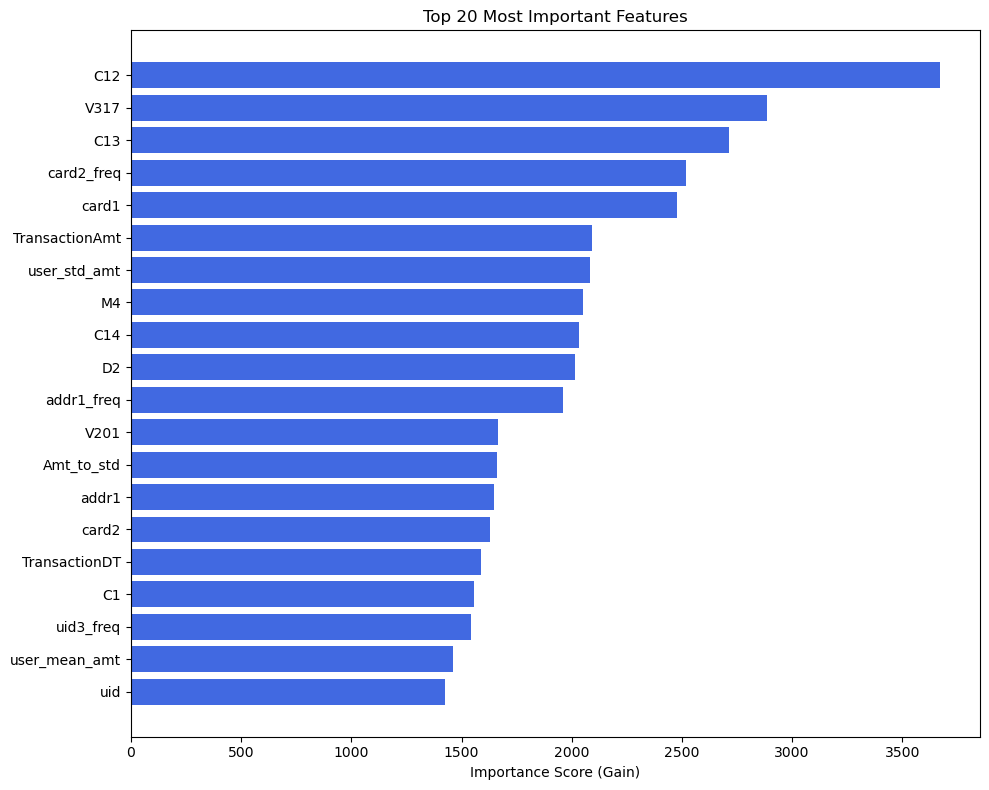

In [30]:
# ==========================================
# 6. FEATURE IMPORTANCE ANALYSIS (Updated)
# ==========================================

def analyze_feature_importance(model, feature_names, top_n=20):
    """
    Computes and plots the top-N most important features.
    Works for:
        - LightGBM (feature_importance: gain)
        - RandomForest (feature_importances_)
    """
    
    # --- Get importance values depending on model type ---
    if hasattr(model, 'feature_importance'):  
        # LightGBM model
        importance = model.feature_importance(importance_type='gain')
    elif hasattr(model, 'feature_importances_'):
        # RandomForest or other sklearn models
        importance = model.feature_importances_
    else:
        print("Model does not support feature importance.")
        return None
    
    # --- Create importance dataframe ---
    feature_importance_df = (
        pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )
    
    print("\n Top Feature Importances:")
    print(feature_importance_df.head(top_n))
    
    # --- Plot top-N features ---
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(top_n)
    
    plt.barh(top_features['feature'], top_features['importance'], color='royalblue')
    plt.xlabel("Importance Score (Gain)")
    plt.title(f"Top {top_n} Most Important Features")
    plt.gca().invert_yaxis()  # highest importance on top
    plt.tight_layout()
    plt.show()
    
    return feature_importance_df


# Run Importance Analysis using LightGBM model
if 'models' in locals():
    print("=== FEATURE IMPORTANCE ANALYSIS ===")
    feature_importance = analyze_feature_importance(
        models['lgb'],              # use LightGBM because it gives best & meaningful importance
        X_train.columns.tolist(),   # all 443 features
        top_n=20
    )
